# Fase 1 v3 — Preparación del corpus turístico (15 centros)

**Alcance:** ETL, limpieza, normalización e integración del corpus de 15 centros turísticos.
En esta fase **no se entrena ni evalúa ningún modelo**; **SBERT se usará en Fase 2**, no aquí.

- **Aspectos (8):** atractivos, costos, seguridad, accesibilidad, limpieza, atencion_servicio,
  gastronomia, alojamiento. *Clima y aforo se tratan como variables contextuales en Fase 4, no como aspectos ABSA.*
- **Diccionario:** se carga el editable `data/diccionario_aspectos.json` (solo para inspección de cobertura,
  no clasifica polaridad). La comparación diccionario vs SBERT y el ABSA de polaridad son Fase 2.
- **Salida:** `data/processed/tourism_reviews_clean.csv` (insumo de Fase 2).

In [1]:
from pathlib import Path
import json, re, hashlib, unicodedata
from datetime import datetime
from typing import Any, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
for d in [DATA_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Umbral de longitud para ABSA: determinado empíricamente en versiones previas
# (curva de cobertura de aspectos + codo de saturación) En esta ejecución el umbral empírico resultó ser de 6 palabras.
MIN_WORDS_ABSA_EMPIRICO = 6
MIN_WORDS_ABSA = MIN_WORDS_ABSA_EMPIRICO

PERSONAL_COLUMNS = ["name", "userName", "reviewerName", "reviewerId", "reviewerUrl",
                    "reviewerPhotoUrl", "reviewerNumberOfReviews", "author"]
print("BASE_DIR:", BASE_DIR)
print("Umbral ABSA:", MIN_WORDS_ABSA, "palabras")

BASE_DIR: d:\Tesis\Tesis_Final\ABSA_Turismo_Fase1_V3
Umbral ABSA: 6 palabras


> El análisis empírico del corpus de 15 centros turísticos seleccionó un umbral mínimo de 6 palabras para el corpus ABSA.

## Registro maestro de los 15 centros

In [2]:
# ============================================================
# 2. REGISTRO MAESTRO DE CENTROS TURÍSTICOS (15 centros)
# ============================================================

CENTROS_TURISTICOS = [
    {"destination_id": "machu_picchu", "destination": "Santuario Histórico de Machu Picchu", "region": "Cusco", "tipo_experiencia": "arqueológico-cultural-natural", "intereses": "cultura, naturaleza, aventura, académico", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "ollantaytambo", "destination": "Sitio Arqueológico de Ollantaytambo", "region": "Cusco", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, historia, aventura", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "saqsayhuaman", "destination": "Parque Arqueológico de Sacsayhuamán", "region": "Cusco", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, historia, fotografía", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "ciudadela_kuelap", "destination": "Ciudadela de Kuélap", "region": "Amazonas", "tipo_experiencia": "arqueológico-natural", "intereses": "cultura, naturaleza, aventura", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "chan_chan", "destination": "Complejo Arqueológico Chan Chan", "region": "La Libertad", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, historia, académico", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "huaca_sol_luna", "destination": "Huacas del Sol y de la Luna", "region": "La Libertad", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, historia, académico", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "huaca_pucllana", "destination": "Museo de Sitio Huaca Pucllana", "region": "Lima", "tipo_experiencia": "arqueológico-urbano", "intereses": "cultura, urbano, gastronomía", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "pachacamac", "destination": "Santuario Arqueológico de Pachacámac", "region": "Lima", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, historia, académico", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "parque_aguas", "destination": "Circuito Mágico del Agua", "region": "Lima", "tipo_experiencia": "urbano-recreativo", "intereses": "urbano, familiar, relax", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "tumbas_sipan", "destination": "Museo Tumbas Reales del Señor de Sipán", "region": "Lambayeque", "tipo_experiencia": "cultural-museístico", "intereses": "cultura, académico, familiar", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "lineas_nazca", "destination": "Líneas y Geoglifos de Nasca y Palpa", "region": "Ica", "tipo_experiencia": "arqueológico-cultural", "intereses": "cultura, aventura, fotografía", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "reserva_paracas", "destination": "Reserva Nacional de Paracas", "region": "Ica", "tipo_experiencia": "natural-playa", "intereses": "naturaleza, playa, aventura, relax", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "valle_colca", "destination": "Valle del Colca", "region": "Arequipa", "tipo_experiencia": "natural-rural", "intereses": "naturaleza, rural, aventura, relax", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
    {"destination_id": "parque_huascaran", "destination": "Parque Nacional Huascarán", "region": "Áncash", "tipo_experiencia": "natural-aventura", "intereses": "naturaleza, aventura, montañismo", "fuente_oficial": "SERNANP / MINCETUR", "estado": "mantener"},
    {"destination_id": "catarata_ahuashiyacu", "destination": "Catarata de Ahuashiyacu", "region": "San Martín", "tipo_experiencia": "natural-aventura", "intereses": "naturaleza, aventura, relax", "fuente_oficial": "MINCETUR / DatosTurismo", "estado": "mantener"},
]

centros_df = pd.DataFrame(CENTROS_TURISTICOS)
centros_df.to_csv(DATA_DIR / "registro_maestro_centros_turisticos.csv", index=False, encoding="utf-8-sig")
print("Centros en el registro:", len(centros_df))
display(centros_df[["destination_id", "destination", "region"]])


Centros en el registro: 15


,destination_id,destination,region
0,machu_picchu,Santuario Histórico de Machu Picchu,Cusco
1,ollantaytambo,Sitio Arqueológico de Ollantaytambo,Cusco
2,saqsayhuaman,Parque Arqueológico de Sacsayhuamán,Cusco
3,ciudadela_kuelap,Ciudadela de Kuélap,Amazonas
4,chan_chan,Complejo Arqueológico Chan Chan,La Libertad
5,huaca_sol_luna,Huacas del Sol y de la Luna,La Libertad
6,huaca_pucllana,Museo de Sitio Huaca Pucllana,Lima
7,pachacamac,Santuario Arqueológico de Pachacámac,Lima
8,parque_aguas,Circuito Mágico del Agua,Lima
9,tumbas_sipan,Museo Tumbas Reales del Señor de Sipán,Lambayeque


## Funciones (reusadas y probadas)

In [3]:
# ============================================================
# FUNCIONES (limpieza con fix HTML, dedup, loader) — reusadas y probadas
# ============================================================

RE_SPACES = re.compile(r"\s+")
RE_URL = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
RE_HTML = re.compile(r"<[^>]+>")
RE_NONWORD = re.compile(r"[^\w\s]", re.UNICODE)

PERSONAL_COLUMNS = [
    "name", "userName", "username", "userId", "userUrl", "userProfile",
    "profileUrl", "avatar", "avatarUrl", "reviewerName", "reviewerId",
    "reviewerUrl", "reviewerPhotoUrl", "reviewerNumberOfReviews",
    "isLocalGuide", "author", "authorName", "authorUrl", "ownerResponseFrom"
]


def normalize_spaces(text: str) -> str:
    return RE_SPACES.sub(" ", (text or "")).strip()


def normalize_text(text: str) -> str:
    """Limpieza mínima compatible con BERT: no elimina tildes ni stopwords."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = RE_HTML.sub(" ", text)
    text = (text.replace("&nbsp;", " ").replace("&amp;", "&")
                .replace("&quot;", '"').replace("&#39;", "'").replace("&gt;", ">").replace("&lt;", "<"))
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = RE_URL.sub(" ", text)
    text = normalize_spaces(text)
    return text


def count_words(text: str) -> int:
    """Cuenta palabras ignorando URLs."""
    t = RE_URL.sub(" ", text or "")
    return len([w for w in re.split(r"\s+", t.strip()) if w])


def make_text_signature(text: str) -> str:
    """Firma para deduplicar por contenido."""
    t = (text or "").lower()
    t = RE_URL.sub(" ", t)
    t = RE_NONWORD.sub(" ", t)
    t = normalize_spaces(t)
    return t


# ------------------------------------------------------------
# Detección de aspectos y relevancia de contenido (mejora Fase 1)
# Léxico bilingüe es/en centralizado. Convención de claves:
#   'kw*' -> coincidencia por RAÍZ/prefijo (hermos* => hermoso/hermosa/hermosos)
#   'kw'  -> coincidencia EXACTA de palabra; las frases (con espacio) van exactas.
# La normalización quita tildes y pasa a minúsculas, por eso las claves coinciden
# aunque el texto lleve acentos. Se reutiliza en el gold set (Sección 11).
# ------------------------------------------------------------

def normalize_for_detection(text: str) -> str:
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = re.sub(r"[^a-z0-9ñ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Léxico de aspectos (8): se CARGA del JSON editable data/diccionario_aspectos.json.
ASPECT_KEYWORDS = json.load(open(DATA_DIR / "diccionario_aspectos.json", encoding="utf-8"))
ASPECT_KEYWORDS = {k: v for k, v in ASPECT_KEYWORDS.items() if not str(k).startswith("_") and isinstance(v, list)}
ASPECTOS_VALIDOS = list(ASPECT_KEYWORDS.keys())
print("Aspectos (8) cargados del diccionario:", ASPECTOS_VALIDOS)

# Léxico de OPINIÓN/valoración (es/en): señala que la reseña EVALÚA algo, aunque no
# nombre un aspecto explícito. Incluye adjetivos valorativos que también son aspecto.
OPINION_LEXICON = [
    # --- es positivo ---
    "recomiend*", "recomendabl*", "excelente*", "buenisim*", "buen", "bueno", "buena", "buenos", "buenas",
    "bonit*", "bell*", "hermos*", "lind*", "precios*", "espectacular*", "maravillos*", "increibl*",
    "impresionante*", "fascin*", "encant*", "genial", "perfect*", "agradabl*", "comod*", "tranquil*",
    "limpi*", "ordenad*", "amable*", "atent*", "rico", "rica", "delicios*", "sabros*", "barat*",
    "economic*", "vale la pena", "disfrut*", "satisf*", "volveria", "regresaria", "imperdible",
    # --- es negativo ---
    "malisim*", "mal", "mala", "malo", "malos", "malas", "peor", "pesim*", "fatal", "horribl*",
    "terribl*", "feo", "fea", "suci*", "caro", "cara", "caros", "caras", "carisim*", "sobreprecio",
    "peligros*", "insegur*", "decepcion*", "aburrid*", "lleno", "llena", "saturad*", "desagradabl*",
    "grosero*", "grosera*", "lent*", "descuidad*", "no recomiend*", "no vale la pena",
    # --- en positivo ---
    "recommend*", "excellent", "great", "good", "nice", "lovely", "beautiful", "gorgeous", "stunning",
    "amazing", "wonderful", "awesome", "fantastic", "perfect", "friendly", "clean", "cheap",
    "affordable", "delicious", "tasty", "enjoy*", "worth", "love*", "lik*", "comfortable", "helpful",
    "safe", "quick",
    # --- en negativo ---
    "bad", "worst", "terribl*", "awful", "horribl*", "disappoint*", "boring", "dirty", "filthy",
    "expensive", "overpriced", "crowded", "rude", "unsafe", "dangerous", "slow", "poor",
    # --- evaluativos adicionales (es) ---
    "interesante*", "admirabl*", "majestuos*", "imponente*", "magnific*", "esplendid*",
    "valios*", "acogedor*", "relajante*", "divertid*", "entretenid*", "encantador*",
    "deplorable", "lamentable", "mediocre", "incomod*", "caotic*", "desorganizad*", "horroros*",
    # --- evaluativos adicionales (en) ---
    "breathtaking", "must see", "must visit", "interesting", "incredible", "spectacular",
    "magnificent", "impressive", "marvel*", "fabulous", "superb", "outstanding", "charming",
    "relaxing", "fun", "enjoyable", "pleasant", "picturesque", "priceless", "worthwhile",
    "unpleasant", "overrated", "underwhelming", "chaotic",
]


def _term_to_pattern(kw: str):
    """Convierte una clave del léxico en regex; raíz/prefijo si termina en '*'."""
    es_raiz = kw.endswith("*")
    kw_norm = normalize_for_detection(kw.rstrip("*"))
    if not kw_norm:
        return None
    sufijo = r"\w*" if es_raiz else r"(?!\w)"
    return r"(?<!\w)" + re.escape(kw_norm) + sufijo


def _algun_termino(normalized: str, terminos) -> bool:
    for kw in terminos:
        patron = _term_to_pattern(kw)
        if patron and re.search(patron, normalized):
            return True
    return False


def detect_aspects(text: str):
    """Categorías de aspecto candidatas mencionadas en el texto."""
    normalized = normalize_for_detection(text)
    return [aspect for aspect, kws in ASPECT_KEYWORDS.items() if _algun_termino(normalized, kws)]


_TODOS_TERMINOS_ASPECTO = [t for kws in ASPECT_KEYWORDS.values() for t in kws]


def es_resena_evaluable(text: str) -> bool:
    """True si la reseña expresa VALORACIÓN/opinión (criterio recomendado, Fase 1).
    Los textos puramente informativos/descriptivos, aunque nombren un aspecto, se
    consideran NO evaluables. La variante conservadora vive en el notebook alterno."""
    normalized = normalize_for_detection(text)
    if not normalized:
        return False
    return _algun_termino(normalized, OPINION_LEXICON)


def remove_accents(text: str) -> str:
    text = str(text)
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )


def slugify(text: str) -> str:
    text = remove_accents(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def language_family(value: Any) -> str:
    value = str(value).strip().lower()
    if value in ["", "nan", "none", "null"]:
        return "sin_dato"
    if value.startswith("es"):
        return "es"
    if value.startswith("en"):
        return "en"
    return "otro"


def classify_sentiment_by_stars(stars: Any) -> str:
    try:
        stars = int(float(stars))
    except Exception:
        return "sin_estrella"
    if stars in [1, 2]:
        return "negativo"
    if stars == 3:
        return "neutro"
    if stars in [4, 5]:
        return "positivo"
    return "sin_estrella"


def load_json_file(path: Path) -> List[Dict[str, Any]]:
    if not path.exists():
        return []

    try:
        with open(path, "r", encoding="utf-8-sig") as f:
            data = json.load(f)
    except json.JSONDecodeError:
        # Soporte JSON Lines
        rows = []
        with open(path, "r", encoding="utf-8-sig") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
        return [x for x in rows if isinstance(x, dict)]

    if isinstance(data, list):
        return [x for x in data if isinstance(x, dict)]
    if isinstance(data, dict):
        for key in ["items", "data", "results", "reviews"]:
            if isinstance(data.get(key), list):
                return [x for x in data[key] if isinstance(x, dict)]
        return [data]
    return []


def extract_first(item: Dict[str, Any], candidates: List[str], default=""):
    for c in candidates:
        # Soporta rutas anidadas tipo "location.lat" -> item["location"]["lat"].
        if "." in c:
            value = item
            for part in c.split("."):
                value = value.get(part) if isinstance(value, dict) else None
                if value is None:
                    break
        else:
            value = item.get(c)
        if value is not None and str(value).strip() != "":
            return value
    return default


def infer_destination_and_scrape_language(path: Path):
    """Infiere destino e idioma desde nombres tipo *_español.json / *_Ingles.json."""
    stem = remove_accents(path.stem).lower()
    stem = stem.replace(" ", "_")
    stem = re.sub(r"^dataset_google_maps_reviews_scraper_", "", stem)
    stem = re.sub(r"^dataset_google-maps-reviews-scraper_", "", stem)

    scrape_language = "desconocido"
    destino_raw = stem

    if re.search(r"_(espanol|spanish|es_419|es)$", stem):
        scrape_language = "es"
        destino_raw = re.sub(r"_(espanol|spanish|es_419|es)$", "", stem)
    elif re.search(r"_(ingles|english|en)$", stem):
        scrape_language = "en"
        destino_raw = re.sub(r"_(ingles|english|en)$", "", stem)

    destino_key = slugify(destino_raw)
    return destino_key, scrape_language


# Mapeo flexible de nombres de archivo a destination_id
FILENAME_TO_DESTINATION_ID = {
    "machu_picchu": "machu_picchu",
    "arqueologico_ollantaytambo": "ollantaytambo",
    "ollantaytambo": "ollantaytambo",
    "saqsayhuaman": "saqsayhuaman",
    "ciudadela_kuelap": "ciudadela_kuelap",
    "kuelap": "ciudadela_kuelap",
    "chan_chan": "chan_chan",
    "huaca_luna": "huaca_sol_luna",
    "huaca_pucllana": "huaca_pucllana",
    "museo_pachacamac": "pachacamac",
    "pachacamac": "pachacamac",
    "parque_aguas": "parque_aguas",
    "museo_sipan": "tumbas_sipan",
    "tumbas_sipan": "tumbas_sipan",
    "lineas_nazca": "lineas_nazca",
    "reserva_paracas": "reserva_paracas",
    "valle_colca": "valle_colca",
    "parque_huascaran": "parque_huascaran",
    "catarata_ahuashiyacu": "catarata_ahuashiyacu",
}

CENTER_BY_ID = centros_df.set_index("destination_id").to_dict(orient="index")


def standardize_apify_row(item: Dict[str, Any], source_file: str, source_row_number: int, destino_key: str, scrape_language: str) -> Dict[str, Any]:
    destination_id = FILENAME_TO_DESTINATION_ID.get(destino_key, destino_key)
    center_meta = CENTER_BY_ID.get(destination_id, {})

    text_raw = extract_first(item, ["text", "reviewText", "review_text", "reviewBody", "content"], "")
    text_clean = normalize_text(text_raw)

    review_id = str(extract_first(item, ["reviewId", "review_id", "id", "cid"], "")).strip()

    original_language = extract_first(item, ["originalLanguage", "language", "detectedLanguage"], "")
    language_review = language_family(original_language)
    if language_review != "sin_dato":
        language_review_source = "review_metadata"
    elif scrape_language in ["es", "en"]:
        # Fallback: si Apify no entrega idioma, usamos el idioma de extracción como aproximación.
        language_review = scrape_language
        language_review_source = "scrape_language"
    else:
        language_review_source = "sin_dato"

    stars = extract_first(item, ["stars", "rating", "reviewRating"], np.nan)

    return {
        "reviewId": review_id,
        "destination_id": destination_id,
        "destination": center_meta.get("destination", destino_key.replace("_", " ").title()),
        "region": center_meta.get("region", ""),
        "tipo_experiencia": center_meta.get("tipo_experiencia", ""),
        "intereses": center_meta.get("intereses", ""),
        "source": "Google Maps",
        "source_file": source_file,
        "source_row_number": source_row_number,
        "scrape_language": scrape_language,
        "language_review": language_review,
        "language_review_source": language_review_source,
        "originalLanguage": original_language,
        "text_raw": text_raw,
        "text_clean": text_clean,
        "text_signature": make_text_signature(text_clean),
        "num_words": count_words(text_clean),
        "stars": stars,
        "sentiment_by_stars": classify_sentiment_by_stars(stars),
        "publishedAtDate": extract_first(item, ["publishedAtDate", "publishedAt", "published_at", "date", "reviewDate", "reviewTime"], ""),
        "publishAt": extract_first(item, ["publishAt"], ""),
        "likesCount": extract_first(item, ["likesCount", "likes_count"], ""),
        "reviewOrigin": extract_first(item, ["reviewOrigin"], ""),
        "placeId": extract_first(item, ["placeId", "place_id"], ""),
        "title": extract_first(item, ["title", "placeTitle"], ""),  # sin "name": evita filtrar el nombre del reviewer
        "url": extract_first(item, ["url", "placeUrl", "reviewUrl"], ""),
        "categoryName": extract_first(item, ["categoryName"], ""),
        "categories": extract_first(item, ["categories"], ""),
        "totalScore": extract_first(item, ["totalScore"], ""),
        "reviewsCount": extract_first(item, ["reviewsCount"], ""),
        "lat": extract_first(item, ["location.lat", "lat", "latitude"], ""),
        "lng": extract_first(item, ["location.lng", "lng", "longitude"], ""),
        "countryCode": extract_first(item, ["countryCode"], ""),
        "has_textTranslated": bool(str(item.get("textTranslated", "")).strip()),
    }


def make_review_uid(row: pd.Series) -> str:
    review_id = str(row.get("reviewId", "")).strip()
    if review_id:
        base = f"googlemaps_{review_id}"
    else:
        base = f"{row.get('destination_id','')}|{row.get('publishedAtDate','')}|{row.get('stars','')}|{row.get('text_signature','')}"
    return "gm_" + hashlib.sha1(base.encode("utf-8")).hexdigest()[:16]


def deduplicate_reviews(df: pd.DataFrame, min_words: int, label: str):
    df = df.copy()
    df = df[df["num_words"] >= min_words].copy()

    before = len(df)

    # Prioridad: conservar fila cuyo idioma de extracción coincide con el idioma de la reseña.
    df["priority_language_match"] = (df["language_review"] == df["scrape_language"]).astype(int)
    df["priority_no_translation"] = (~df["has_textTranslated"].astype(bool)).astype(int)

    # 1) Deduplicación por reviewId si existe
    with_id = df[df["reviewId"].astype(str).str.strip() != ""].copy()
    without_id = df[df["reviewId"].astype(str).str.strip() == ""].copy()

    with_id = with_id.sort_values(
        by=["reviewId", "priority_language_match", "priority_no_translation", "num_words"],
        ascending=[True, False, False, False]
    )

    dedup_id = with_id.drop_duplicates(subset=["reviewId"], keep="first").copy()
    removed_dup_id = len(with_id) - len(dedup_id)

    # 2) Deduplicación por firma textual dentro del mismo destino
    merged = pd.concat([dedup_id, without_id], ignore_index=True)
    before_text = len(merged)

    merged = merged.sort_values(
        by=["destination_id", "text_signature", "priority_language_match", "priority_no_translation", "num_words"],
        ascending=[True, True, False, False, False]
    )

    final = merged.drop_duplicates(subset=["destination_id", "text_signature"], keep="first").copy()
    removed_dup_text = before_text - len(final)

    final["review_uid"] = final.apply(make_review_uid, axis=1)

    report = {
        "dataset": label,
        "min_words": min_words,
        "filas_entrada": before,
        "duplicados_por_reviewId_eliminados": int(removed_dup_id),
        "duplicados_por_texto_eliminados": int(removed_dup_text),
        "filas_finales": len(final)
    }

    return final, report


Aspectos (8) cargados del diccionario: ['atractivos', 'costos', 'seguridad', 'accesibilidad', 'limpieza', 'atencion_servicio', 'gastronomia', 'alojamiento']


## Carga de los 15 JSON

In [4]:
# ============================================================
# CARGA DE LOS 15 JSON (Google Maps)
# ============================================================
json_files = sorted(DATA_DIR.glob("dataset_Google-Maps-Reviews-Scraper_*.json"))
if not json_files:
    raise FileNotFoundError("No se encontraron JSON en data/.")
print("Archivos JSON encontrados:", len(json_files))

rows = []
for path in json_files:
    items = load_json_file(path)
    destino_key, scrape_language = infer_destination_and_scrape_language(path)
    for idx, item in enumerate(items, 1):
        rows.append(standardize_apify_row(item, path.name, idx, destino_key, scrape_language))

raw_df = pd.DataFrame(rows)
print("Reseñas crudas cargadas:", len(raw_df))
display(raw_df.groupby("destination").size().rename("crudas").reset_index())

Archivos JSON encontrados: 15
Reseñas crudas cargadas: 26331


,destination,crudas
0,Catarata de Ahuashiyacu,2108
1,Circuito Mágico del Agua,1500
2,Ciudadela de Kuélap,1500
3,Complejo Arqueológico Chan Chan,1838
4,Huacas del Sol y de la Luna,1971
5,Líneas y Geoglifos de Nasca y Palpa,2462
6,Museo Tumbas Reales del Señor de Sipán,1500
7,Museo de Sitio Huaca Pucllana,1500
8,Parque Arqueológico de Sacsayhuamán,1500
9,Parque Nacional Huascarán,2952


## Estandarización y filtros base

In [5]:
# ============================================================
# ESTANDARIZACIÓN + FILTROS BASE (vacías, idioma es/en)
# ============================================================
raw_df = raw_df.drop(columns=[c for c in PERSONAL_COLUMNS if c in raw_df.columns], errors="ignore")
n_crudas = len(raw_df)

raw_df["text_clean"] = raw_df["text_clean"].fillna("").astype(str).apply(normalize_text)
raw_df["text_signature"] = raw_df["text_clean"].apply(make_text_signature)
raw_df["num_words"] = raw_df["text_clean"].apply(count_words)
raw_df["reviewId"] = raw_df["reviewId"].fillna("").astype(str).str.strip()
raw_df["stars"] = pd.to_numeric(raw_df["stars"], errors="coerce")
raw_df["sentiment_by_stars"] = raw_df["stars"].apply(classify_sentiment_by_stars)
raw_df["language_review"] = raw_df["language_review"].fillna("sin_dato").astype(str).str.lower()

empty_mask = raw_df["text_clean"].str.strip().eq("")
lang_mask = raw_df["language_review"].isin(["es", "en"])
crudo = raw_df[(~empty_mask) & lang_mask & (raw_df["num_words"] >= 1)].copy()

embudo = [
    {"etapa": "reseñas_crudas", "cantidad": n_crudas},
    {"etapa": "vacias_eliminadas", "cantidad": int(empty_mask.sum())},
    {"etapa": "idioma_no_es_en_eliminado", "cantidad": int((~lang_mask).sum())},
    {"etapa": "crudo_controlado", "cantidad": len(crudo)},
]
print("Crudo controlado:", len(crudo))

Crudo controlado: 22677


## Determinación empírica del umbral de palabras

Método 1 (cobertura >= 75%): umbral = 1  (satura: poco discriminante)
Método 2 (codo de saturación): umbral = 11
>> UMBRAL ABSA ADOPTADO: 6 palabras (compromiso retención/señal)


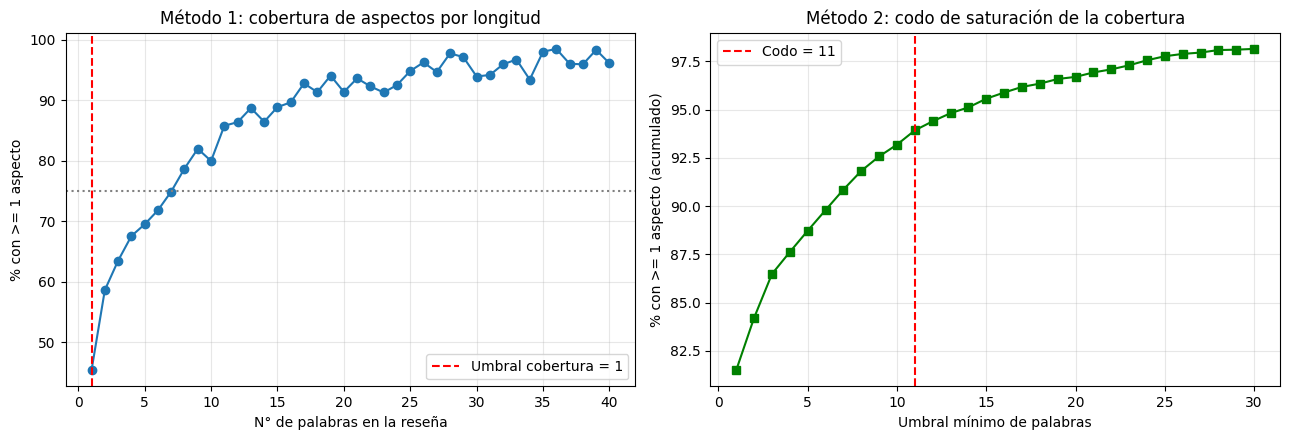

In [6]:
# ============================================================
# DETERMINACIÓN EMPÍRICA DEL UMBRAL DE PALABRAS PARA ABSA
# ============================================================
# Con data NUEVA el umbral se RE-ESTIMA (no se hereda de versiones previas):
#   Método 1 — Curva de cobertura: primer umbral con >= 75% de reseñas con >= 1 aspecto.
#   Método 2 — Codo / saturación (rodilla) de la curva de cobertura acumulada.
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
UMBRAL_COBERTURA = 0.75

def detectar_codo(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if len(x) < 3 or x.max() == x.min() or y.max() == y.min():
        return None
    xn = (x - x.min()) / (x.max() - x.min()); yn = (y - y.min()) / (y.max() - y.min())
    x0, y0, x1, y1 = xn[0], yn[0], xn[-1], yn[-1]
    d = np.abs((y1 - y0) * xn - (x1 - x0) * yn + x1 * y0 - y1 * x0) / np.hypot(y1 - y0, x1 - x0)
    return int(x[int(np.argmax(d))])

# Cobertura de aspectos por longitud (usa el diccionario cargado = detect_aspects)
um = crudo[["text_clean", "num_words"]].copy()
um["n_aspectos"] = um["text_clean"].apply(lambda t: len(detect_aspects(t)))
um["tiene_aspecto"] = (um["n_aspectos"] >= 1).astype(int)

curva = pd.DataFrame([
    {"palabras": w, "%_con_aspecto": round(100 * um.loc[um["num_words"] == w, "tiene_aspecto"].mean(), 2)}
    for w in range(1, 41) if (um["num_words"] == w).any()
])
total = len(um)
acum = pd.DataFrame([
    {"umbral": w, "%_corpus": round(100 * (um["num_words"] >= w).sum() / total, 2),
     "%_con_aspecto": round(100 * um.loc[um["num_words"] >= w, "tiene_aspecto"].mean(), 2)}
    for w in range(1, 31) if (um["num_words"] >= w).any()
])

cand = acum[acum["%_con_aspecto"] >= UMBRAL_COBERTURA * 100]
m1 = int(cand["umbral"].iloc[0]) if len(cand) else None
m2 = detectar_codo(acum["umbral"].values, acum["%_con_aspecto"].values)
nums = [n for n in [m1, m2] if n]
MIN_WORDS_ABSA = int(round(np.mean(nums))) if nums else MIN_WORDS_ABSA_EMPIRICO
# NOTA: el Método 1 (cobertura) satura en un valor bajo porque el diccionario ampliado
# detecta aspectos hasta en reseñas muy cortas; el Método 2 (codo) marca la saturación real.
# El umbral adoptado (promedio) es un COMPROMISO entre retención del corpus y señal de aspecto.
print(f"Método 1 (cobertura >= 75%): umbral = {m1}  (satura: poco discriminante)")
print(f"Método 2 (codo de saturación): umbral = {m2}")
print(f">> UMBRAL ABSA ADOPTADO: {MIN_WORDS_ABSA} palabras (compromiso retención/señal)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(curva["palabras"], curva["%_con_aspecto"], marker="o")
if m1: ax[0].axvline(m1, color="red", ls="--", label=f"Umbral cobertura = {m1}")
ax[0].axhline(75, color="gray", ls=":")
ax[0].set_xlabel("N° de palabras en la reseña"); ax[0].set_ylabel("% con >= 1 aspecto")
ax[0].set_title("Método 1: cobertura de aspectos por longitud"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(acum["umbral"], acum["%_con_aspecto"], marker="s", color="green")
if m2: ax[1].axvline(m2, color="red", ls="--", label=f"Codo = {m2}")
ax[1].set_xlabel("Umbral mínimo de palabras"); ax[1].set_ylabel("% con >= 1 aspecto (acumulado)")
ax[1].set_title("Método 2: codo de saturación de la cobertura"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "fase1_umbral_absa.png", dpi=300); plt.show()

## Corpus limpio (dedup + umbral + relevancia)

In [7]:
# ============================================================
# DEDUPLICACIÓN + UMBRAL 6 PALABRAS + FILTRO DE RELEVANCIA → CORPUS LIMPIO
# ============================================================
absa, rep = deduplicate_reviews(crudo, MIN_WORDS_ABSA, "corpus_absa")

# Filtro de relevancia: descarta textos sin contenido evaluable (auditable).
mask_eval = absa["text_clean"].apply(es_resena_evaluable)
n_pre = len(absa)
absa = absa[mask_eval].copy()

embudo += [
    {"etapa": "candidato_absa_min_6_palabras", "cantidad": int(rep["filas_entrada"])},
    {"etapa": "duplicados_eliminados", "cantidad": int(rep["duplicados_por_reviewId_eliminados"] + rep["duplicados_por_texto_eliminados"])},
    {"etapa": "informativas_descartadas", "cantidad": int(n_pre - len(absa))},
    {"etapa": "corpus_absa_limpio", "cantidad": len(absa)},
]

# Exportación ÚNICA del corpus (insumo de Fase 2). Sin columnas de aspecto (eso es Fase 2).
FINAL_COLS = ["review_uid", "reviewId", "destination_id", "destination", "region", "source",
              "language_review", "stars", "sentiment_by_stars", "publishedAtDate",
              "text_clean", "num_words", "source_file"]
corpus = absa[[c for c in FINAL_COLS if c in absa.columns]].copy()
corpus = corpus.sort_values(["destination", "language_review", "review_uid"]).reset_index(drop=True)
corpus.to_csv(PROCESSED_DIR / "tourism_reviews_clean.csv", index=False, encoding="utf-8-sig")
print("Corpus ABSA limpio:", len(corpus), "-> data/processed/tourism_reviews_clean.csv")

Corpus ABSA limpio: 13740 -> data/processed/tourism_reviews_clean.csv


## Análisis exploratorio

In [8]:
# ============================================================
# EDA (inline, sin generar archivos)
# ============================================================
print("Reseñas por centro:")
display(corpus.groupby("destination").size().rename("n").reset_index().sort_values("n", ascending=False))
print("Por idioma:")
display(corpus["language_review"].value_counts().rename_axis("idioma").reset_index(name="n"))
print("Polaridad por estrellas:")
display(corpus["sentiment_by_stars"].value_counts().rename_axis("sentimiento").reset_index(name="n"))

Reseñas por centro:


,destination,n
12,Santuario Histórico de Machu Picchu,1318
10,Reserva Nacional de Paracas,1100
6,Museo Tumbas Reales del Señor de Sipán,1084
7,Museo de Sitio Huaca Pucllana,1072
8,Parque Arqueológico de Sacsayhuamán,1047
2,Ciudadela de Kuélap,1026
1,Circuito Mágico del Agua,964
11,Santuario Arqueológico de Pachacámac,942
13,Sitio Arqueológico de Ollantaytambo,931
9,Parque Nacional Huascarán,923


Por idioma:


,idioma,n
0,es,7269
1,en,6471


Polaridad por estrellas:


,sentimiento,n
0,positivo,12931
1,neutro,489
2,negativo,320


## Cobertura del diccionario sobre el corpus

In [9]:
# ============================================================
# COBERTURA DEL DICCIONARIO (8 aspectos) SOBRE EL CORPUS LIMPIO
# ============================================================
det = corpus["text_clean"].apply(detect_aspects)
n_asp = det.apply(len)
cobertura_global = (n_asp >= 1).mean() * 100
print(f"Cobertura global del diccionario: {cobertura_global:.1f}% ({int((n_asp>=1).sum())}/{len(corpus)})")
print(f"Sin aspecto: {int((n_asp==0).sum())} ({100*(n_asp==0).mean():.1f}%)")

filas = [{"aspecto": a, "n_reseñas": int(det.apply(lambda L: a in L).sum())} for a in ASPECTOS_VALIDOS]
cobertura_aspecto = pd.DataFrame(filas)
cobertura_aspecto["%_corpus"] = (100 * cobertura_aspecto["n_reseñas"] / len(corpus)).round(2)
cobertura_aspecto = cobertura_aspecto.sort_values("n_reseñas", ascending=False).reset_index(drop=True)
display(cobertura_aspecto)
cobertura_aspecto.to_csv(OUTPUT_DIR / "cobertura_diccionario_por_aspecto.csv", index=False, encoding="utf-8-sig")

Cobertura global del diccionario: 93.2% (12807/13740)
Sin aspecto: 933 (6.8%)


,aspecto,n_reseñas,%_corpus
0,atractivos,11484,83.58
1,accesibilidad,3700,26.93
2,costos,3448,25.09
3,atencion_servicio,3199,23.28
4,gastronomia,1397,10.17
5,limpieza,1277,9.29
6,alojamiento,620,4.51
7,seguridad,507,3.69


## Visualizaciones (figuras para la tesis)

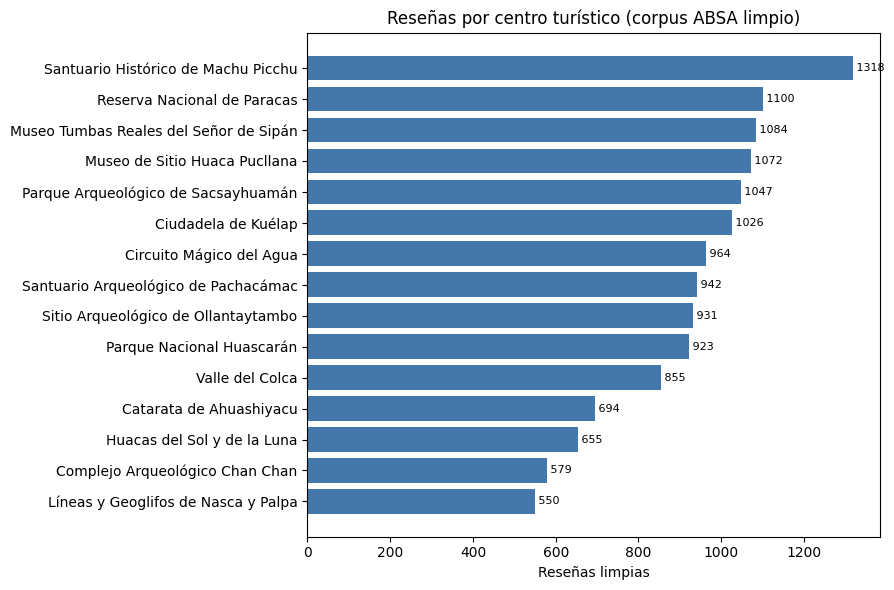

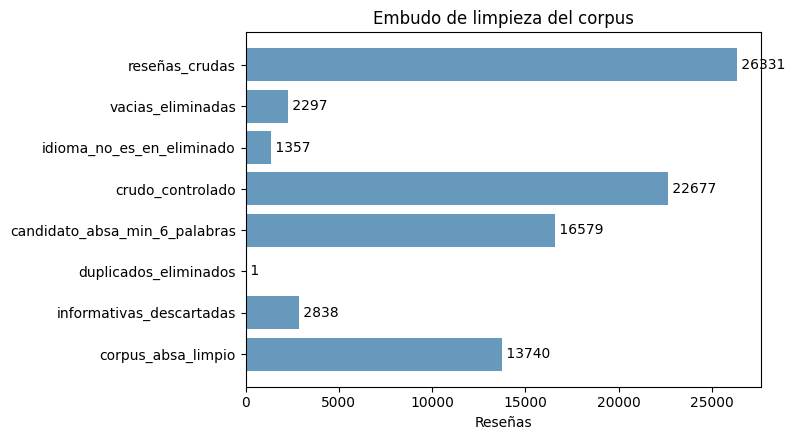

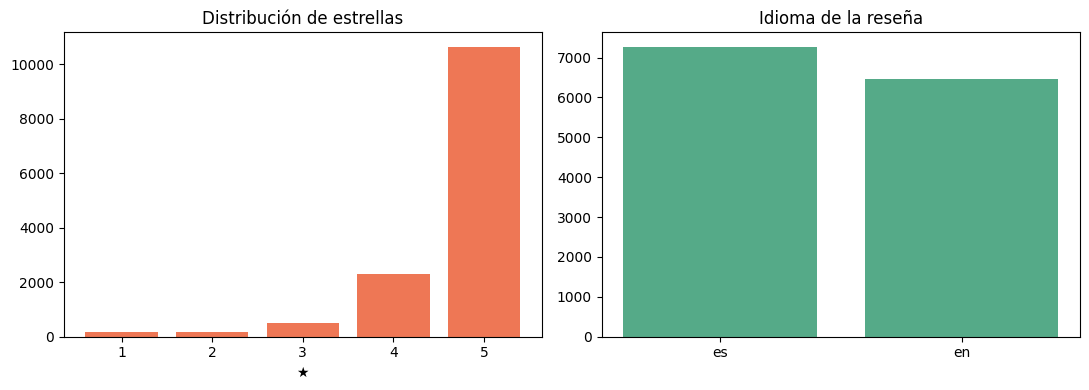

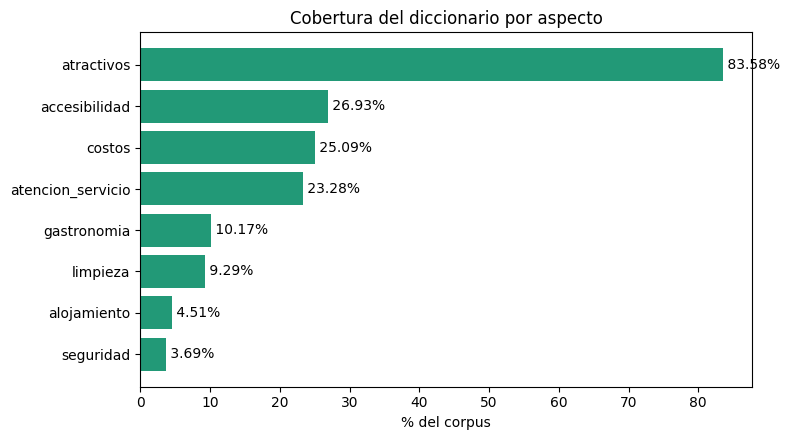

Figuras Fase 1 -> outputs/figures/


In [10]:
# ============================================================
# VISUALIZACIONES (figuras para la tesis)
# ============================================================
import matplotlib.pyplot as plt
FIG = BASE_DIR / "outputs" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# 1) Reseñas por centro
pc = corpus.groupby("destination").size().sort_values()
plt.figure(figsize=(9, 6)); plt.barh(pc.index, pc.values, color="#4477aa")
for i, v in enumerate(pc.values): plt.text(v, i, f" {v}", va="center", fontsize=8)
plt.xlabel("Reseñas limpias"); plt.title("Reseñas por centro turístico (corpus ABSA limpio)")
plt.tight_layout(); plt.savefig(FIG / "fase1_resenas_por_centro.png", dpi=300); plt.show()

# 2) Embudo de limpieza
emb = pd.DataFrame(embudo)
plt.figure(figsize=(8, 4.5)); plt.barh(emb["etapa"][::-1], emb["cantidad"][::-1], color="#6699bb")
for i, v in enumerate(emb["cantidad"][::-1]): plt.text(v, i, f" {v}", va="center")
plt.xlabel("Reseñas"); plt.title("Embudo de limpieza del corpus")
plt.tight_layout(); plt.savefig(FIG / "fase1_embudo_limpieza.png", dpi=300); plt.show()

# 3) Estrellas e idioma
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
st = pd.to_numeric(corpus["stars"], errors="coerce").value_counts().sort_index()
ax[0].bar([str(int(i)) for i in st.index], st.values, color="#ee7755")
ax[0].set_title("Distribución de estrellas"); ax[0].set_xlabel("★")
lg = corpus["language_review"].value_counts()
ax[1].bar(lg.index, lg.values, color="#55aa88"); ax[1].set_title("Idioma de la reseña")
plt.tight_layout(); plt.savefig(FIG / "fase1_estrellas_idioma.png", dpi=300); plt.show()

# 4) Cobertura del diccionario por aspecto
ca = cobertura_aspecto.sort_values("%_corpus")
plt.figure(figsize=(8, 4.5)); plt.barh(ca["aspecto"], ca["%_corpus"], color="#229977")
for i, v in enumerate(ca["%_corpus"]): plt.text(v, i, f" {v}%", va="center")
plt.xlabel("% del corpus"); plt.title("Cobertura del diccionario por aspecto")
plt.tight_layout(); plt.savefig(FIG / "fase1_cobertura_diccionario.png", dpi=300); plt.show()
print("Figuras Fase 1 -> outputs/figures/")

## Reporte final

In [11]:
# ============================================================
# REPORTE FINAL (1 archivo: resumen_fase1.csv)
# ============================================================
resumen = pd.DataFrame(embudo)
resumen.to_csv(OUTPUT_DIR / "resumen_fase1.csv", index=False, encoding="utf-8-sig")

print("=" * 60); print("FASE 1 V3 — RESUMEN"); print("=" * 60)
display(resumen)
bajo = corpus.groupby("destination").size()
bajo = bajo[bajo < 400]
if len(bajo):
    print("Centros con bajo soporte (<400 reseñas limpias):")
    print(bajo.to_string())
else:
    print("Todos los centros con soporte >= 400 reseñas limpias.")
print("\nArchivos generados (solo los necesarios):")
print(" - data/processed/tourism_reviews_clean.csv      (corpus para Fase 2)")
print(" - data/registro_maestro_centros_turisticos.csv  (15 centros)")
print(" - outputs/cobertura_diccionario_por_aspecto.csv")
print(" - outputs/resumen_fase1.csv")
print(" - data/diccionario_aspectos.json                (tu diccionario editable, se carga; no se sobrescribe)")

FASE 1 V3 — RESUMEN


,etapa,cantidad
0,reseñas_crudas,26331
1,vacias_eliminadas,2297
2,idioma_no_es_en_eliminado,1357
3,crudo_controlado,22677
4,candidato_absa_min_6_palabras,16579
5,duplicados_eliminados,1
6,informativas_descartadas,2838
7,corpus_absa_limpio,13740


Todos los centros con soporte >= 400 reseñas limpias.

Archivos generados (solo los necesarios):
 - data/processed/tourism_reviews_clean.csv      (corpus para Fase 2)
 - data/registro_maestro_centros_turisticos.csv  (15 centros)
 - outputs/cobertura_diccionario_por_aspecto.csv
 - outputs/resumen_fase1.csv
 - data/diccionario_aspectos.json                (tu diccionario editable, se carga; no se sobrescribe)
